# 1.2 신경망 미니 리뷰 — 실습 노트북

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SuminHan/book-ml/blob/main/notebooks/ml2/chapter01_2_nn_mini_review.ipynb)

책 본문: [1.2 신경망 미니 리뷰](https://smhanlab.com/book-ml/kor/ml2/chapter01/2.html)

이 노트북은 이 절의 "뼈대"를 코드로 직접 확인합니다:
(1) 활성 함수 없는 두 층은 하나의 층으로 완전히 축소된다는 것을 숫자로,
(2) XOR — 1층(선형)으로는 불가능하지만 2층 ReLU 네트워크가 학습하는 결정 경계를 직접,
(3) 1-2-1 신경망의 역전파 손계산이 `.backward()`의 그래디언트와 정확히 일치하는 것을,
(4) 유한차분으로 해석적 미분을 확인하는 "그래디언트 체크"를,
(5) numpy MLP(직접 쓴 역전파)로 비선형 곡선 y=sin(x)를 근사하는 것을,
(6) PyTorch의 세 줄 루프 `zero_grad() → backward() → step()`와 `zero_grad()`를 빼먹으면
무슨 일이 일어나는지(발산)를.


## 1. 활성 함수 없는 두 층 = 하나의 층

본문의 논리를 코드로: \(\sigma\)를 빼고(항등 함수로 교체하면) 선형 변환 두 개의
조성은 여전히 **한 개의 선형 변환**이다. 같은 \(x\)로 "2층" 순전파와
축소된 1층의 출력을 계산해서 차이를 봅니다.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

W1 = rng.normal(size=(3, 4))    # 1층: 입력 4개 -> 은닉 3개
b1 = rng.normal(size=3)
W2 = rng.normal(size=(1, 3))    # 2층: 은닉 3개 -> 출력 1개
b2 = np.array([0.5])

xs = rng.normal(size=(50, 4))

# "2층" 순전파 (활성 함수 없음 — 항등 함수)
Z1 = xs @ W1.T + b1          # (50, 3)
OUT_2L = Z1 @ W2.T + b2      # (50, 1)

# 축소된 1층: W = W2 W1,  b = W2 b1 + b2
W = W2 @ W1
b = W2 @ b1 + b2
OUT_1L = xs @ W.T + b

diff = np.abs(OUT_2L - OUT_1L).max()
print(f"2층(활성 함수 없음)과 축소 1층의 출력 최대 차이: {diff:.2e}")
assert diff < 1e-12
print("-> 활성화가 없으면 층을 몇 개나 쌓아도 '하나의 선형 변환' 하나. ")
print("   깊이(depth)는 비선형 활성이 중간에 있을 때만 의미 있다.")

2층(활성 함수 없음)과 축소 1층의 출력 최대 차이: 8.88e-16
-> 활성화가 없으면 층을 몇 개나 쌓아도 '하나의 선형 변환' 하나. 
   깊이(depth)는 비선형 활성이 중간에 있을 때만 의미 있다.


## 2. 1-2-1 신경망: 역전파 손계산 vs `.backward()`

본문과 똑같은 설정 — 은닉 2유닛(ReLU), 단순한 정수 가중치:

- 은닉층: \(W_1 = [2, -1]^T\), \(b_1 = 0\)
- 출력층: \(W_2 = [1, 1]\), \(b_2 = 0\)
- 입력/정답: \(x = 1\), \(y = 3\), 손실 \(J = (\text{pred} - y)^2\)

**순전파**: \(z_1 = (2, -1)\), \(a_1 = \text{ReLU}(z_1) = (2, 0)\)
(두 번째 유닛이 **죽음**), \(\text{pred} = 2\), \(J = 1\), \(\text{err} = -1\).

**손계산한 그래디언트**: \(\partial J/\partial W_2 = [-4, 0]\),
\(\partial J/\partial b_2 = -2\),
\(\partial J/\partial W_1 = [-2, 0]\), \(\partial J/\partial b_1 = [-2, 0]\).
아래에서 `.backward()`가 채운 `.grad`와 대조합니다.


In [2]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim),
        )
    def forward(self, x):
        return self.net(x)

# 본문 손계산과 똑같은 가중치
m = MLP(1, 2, 1)
with torch.no_grad():
    m.net[0].weight.copy_(torch.tensor([[2.0], [-1.0]]))  # W1
    m.net[0].bias.zero_()                                 # b1 = 0
    m.net[2].weight.copy_(torch.tensor([[1.0, 1.0]]))     # W2
    m.net[2].bias.zero_()                                 # b2 = 0

x = torch.tensor([[1.0]])
y = torch.tensor([[3.0]])

# 순전파
z1 = m.net[0](x)      # (1, 2)
a1 = m.net[1](z1)     # ReLU
pred = m.net[2](a1)
J = ((pred - y) ** 2).mean()

# 역전파
J.backward()

print("순전파: z1 =", z1.detach().numpy().ravel(),
      " a1 =", a1.detach().numpy().ravel(),
      " pred =", pred.item(), " J =", J.item())

hand = {
    "dW2 (출력층 가중치)": (torch.tensor([[-4.0, 0.0]]).numpy(), m.net[2].weight.grad.numpy()),
    "db2 (출력층 편향)  ": (np.array([-2.0]), m.net[2].bias.grad.numpy().ravel()),
    "dW1 (은닉층 가중치)": (np.array([[-2.0], [0.0]]), m.net[0].weight.grad.numpy()),
    "db1 (은닉층 편향)  ": (np.array([-2.0, 0.0]), m.net[0].bias.grad.numpy().ravel()),
}
all_ok = True
for name, (h, g) in hand.items():
    ok = np.allclose(g, h)
    all_ok &= ok
    print(f"{name}: 손계산 {h.ravel()}  autograd {g.ravel()}  일치={ok}")
assert all_ok
print()
print("-> 4개의 값이 전부 정확히 일치. 두 번째(죽은) 유닛의 그래디언트는 0이다.")

순전파: z1 = [ 2. -1.]  a1 = [2. 0.]  pred = 2.0  J = 1.0
dW2 (출력층 가중치): 손계산 [-4.  0.]  autograd [-4.  0.]  일치=True
db2 (출력층 편향)  : 손계산 [-2.]  autograd [-2.]  일치=True
dW1 (은닉층 가중치): 손계산 [-2.  0.]  autograd [-2.  0.]  일치=True
db1 (은닉층 편향)  : 손계산 [-2.  0.]  autograd [-2.  0.]  일치=True

-> 4개의 값이 전부 정확히 일치. 두 번째(죽은) 유닛의 그래디언트는 0이다.


### 유한차분으로 확인하는 그래디언트 체크

본문과 똑같은 단일 가중치 예제: \(\text{pred} = w x_1 + w_2 x_2 + b\)에서
\(w_2 = -0.7\), \(b = 0.2\)는 고정하고 \(w\)만 배운다.
\(x_1 = 0.4\), \(x_2 = 0.9\), \(y = 1.0\), \(J = (\text{pred}-y)^2\).
해석적 미분과 \(\pm 0.001\) 중심차분이 일치하는지 봅니다.


In [3]:
w, w2, b = 0.3, -0.7, 0.2
x1, x2, y = 0.4, 0.9, 1.0

def J(w):
    return (w * x1 + w2 * x2 + b - y) ** 2

analytic = 2 * (w * x1 + w2 * x2 + b - y) * x1    # dJ/dw = 2(pred-y)*x1
eps = 0.001
fd = (J(w + eps) - J(w - eps)) / (2 * eps)        # 중심차분

print(f"pred = {w * x1 + w2 * x2 + b:.4f},  J = {J(w):.6f}")
print(f"해석적 미분  dJ/dw      = {analytic:.4f}")
print(f"J({w + eps:.3f}) = {J(w + eps):.6f},  J({w - eps:.3f}) = {J(w - eps):.6f}")
print(f"중심차분      dJ/dw      = {fd:.4f}")
assert abs(analytic - fd) < 1e-6
print("-> 정확히 일치. 이 '해석적 미분 vs 유한차분' 확인이 그래디언트 체크의 ")
print("   가장 간단한 단위 테스트다 (역전파가 맞는지 검증하는 방법).")

pred = -0.3100,  J = 1.716100
해석적 미분  dJ/dw      = -1.0480
J(0.301) = 1.715052,  J(0.299) = 1.717148
중심차분      dJ/dw      = -1.0480
-> 정확히 일치. 이 '해석적 미분 vs 유한차분' 확인이 그래디언트 체크의 
   가장 간단한 단위 테스트다 (역전파가 맞는지 검증하는 방법).


## 3. XOR: 1층(선형)은 불가능 → 2층 ReLU는 가능

XOR은 **선형 분리 불가능** — 한 개의 직선(선형 모델)으로는 (0,1),(1,0)과
(0,0),(1,1)을 분리할 수 없다. 먼저 1층(선형) 모델이 실제로 뭘 하는지 보고,
이어서 4-유닛 ReLU 2층 네트워크가 어떻게 분리를 학습하는지 결정 경계로 확인한다.


In [4]:
X = torch.tensor([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])
Y = torch.tensor([[0.0], [1.0], [1.0], [0.0]])

torch.manual_seed(0)
lin = nn.Linear(2, 1)                     # 활성 없는 1층 = 선형 모델
opt = torch.optim.Adam(lin.parameters(), lr=0.05)
bce = nn.BCEWithLogitsLoss()
for e in range(300):
    loss = bce(lin(X), Y)
    opt.zero_grad()
    loss.backward()
    opt.step()

with torch.no_grad():
    probs = torch.sigmoid(lin(X)).numpy().ravel()
print("1층(선형) 모델 300 에포크 학습 후:")
print("  loss =", round(loss.item(), 3), "(= ln 2 — '무응답' 상태)")
print("  예측 확률:", probs.round(3).tolist())
print("  정확도 =", ((probs > 0.5).astype(int) == Y.numpy().ravel()).mean())
print("-> '분리'를 포기하고 모든 점에서 0.5를 내보내는 것 외에는 없음을 직접 확인.")

1층(선형) 모델 300 에포크 학습 후:
  loss = 0.693 (= ln 2 — '무응답' 상태)
  예측 확률: [0.5, 0.5, 0.5, 0.5]
  정확도 = 0.5
-> '분리'를 포기하고 모든 점에서 0.5를 내보내는 것 외에는 없음을 직접 확인.


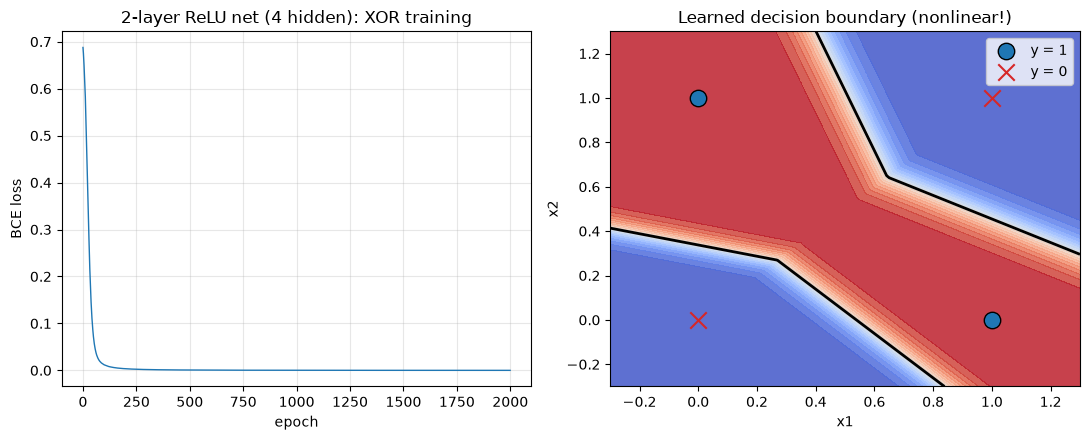

최종 loss = 0.0001
예측 확률: [0.0, 1.0, 1.0, 0.0]  (정답 [0, 1, 1, 0])
-> 4개의 은닉 유닛이 각각 '한 개의 직선' 경계를 만들고, 그 조합이 
   대각선으로 마주 보는 두 집단을 분리는 비선형 경계를 만든다.


In [5]:
torch.manual_seed(0)
model = MLP(2, 4, 1)          # 은닉 4유닛, ReLU
opt = torch.optim.Adam(model.parameters(), lr=0.05)
losses = []
for e in range(2000):
    loss = bce(model(X), Y)
    opt.zero_grad()
    loss.backward()
    opt.step()
    losses.append(loss.item())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(losses, lw=1)
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("BCE loss")
axes[0].set_title("2-layer ReLU net (4 hidden): XOR training")
axes[0].grid(alpha=0.3)

step = 0.01
gx, gy = np.meshgrid(np.arange(-0.3, 1.31, step), np.arange(-0.3, 1.31, step))
grid = torch.tensor(np.c_[gx.ravel(), gy.ravel()], dtype=torch.float32)
with torch.no_grad():
    p = torch.sigmoid(model(grid)).numpy().reshape(gx.shape)
axes[1].contourf(gx, gy, p, levels=20, cmap="coolwarm", alpha=0.85)
axes[1].contour(gx, gy, p, levels=[0.5], colors="k", linewidths=2)
pts = X.numpy()
pos = pts[Y.numpy().ravel() == 1]
neg = pts[Y.numpy().ravel() == 0]
axes[1].scatter(pos[:, 0], pos[:, 1], c="tab:blue", marker="o", s=140,
                edgecolors="k", label="y = 1")
axes[1].scatter(neg[:, 0], neg[:, 1], c="tab:red", marker="x", s=140,
                label="y = 0")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
axes[1].set_title("Learned decision boundary (nonlinear!)")
axes[1].set_xlim(-0.3, 1.3)
axes[1].set_ylim(-0.3, 1.3)
axes[1].legend()

plt.tight_layout()
plt.show()

with torch.no_grad():
    probs = torch.sigmoid(model(X)).numpy().ravel()
print("최종 loss =", round(loss.item(), 4))
print("예측 확률:", probs.round(3).tolist(), " (정답 [0, 1, 1, 0])")
print("-> 4개의 은닉 유닛이 각각 '한 개의 직선' 경계를 만들고, 그 조합이 ")
print("   대각선으로 마주 보는 두 집단을 분리는 비선형 경계를 만든다.")

## 4. 비선형 곡선 y = sin(x) 근사 (numpy MLP — 직접 쓴 역전파)

본문과 똑같은 설정: 입력 1 → 은닉 32(ReLU) → 출력 1, **직접 쓴 numpy 역전파**로
SGD(lr=0.1), 512개 샘플(\(x \in [-2, 2]\)), 800 에포크. "32개의 선형 조각이
이어붙어 곡선이 된다"는 것을 눈으로 확인한다. (극값/양 끝에서 오차가 가장 크다는
본문의 주지도 아래 결과에서 보인다.)


In [6]:
def relu(u):
    return np.maximum(0.0, u)

rng = np.random.default_rng(0)
N, H, lr, epochs = 512, 32, 0.1, 800

x = rng.uniform(-2.0, 2.0, size=(N, 1))
y = np.sin(x)

W1 = rng.normal(size=(1, H)); b1 = np.zeros(H)   # 입력 1 -> 은닉 32
W2 = rng.normal(size=(H, 1)); b2 = np.zeros(1)   # 은닉 32 -> 출력 1

losses = []
for e in range(epochs):
    # ---- 순전파 ----
    z1 = x @ W1 + b1
    a1 = relu(z1)
    pred = a1 @ W2 + b2
    # ---- 역전파 (연쇄법칙) ----
    err = (pred - y) / N           # dJ/dpred  (MSE, mean)
    gW2 = a1.T @ err               # dJ/dW2
    gb2 = err.sum(axis=0)          # dJ/db2
    ga1 = err @ W2.T               # 출력층 오차 신호를 은닉층으로 내려보냄
    gz1 = ga1 * (z1 > 0)           # ReLU 도함수로 필터 (죽은 유닛 -> 0)
    gW1 = x.T @ gz1                # dJ/dW1
    gb1 = gz1.sum(axis=0)          # dJ/db1
    # ---- SGD 업데이트 ----
    W1 -= lr * gW1; b1 -= lr * gb1
    W2 -= lr * gW2; b2 -= lr * gb2
    losses.append(((pred - y) ** 2).mean())

for e in (1, 100, 400, 800):
    print(f"에포크 {e:>4}: MSE = {losses[e - 1]:.4f}")

에포크    1: MSE = 3.9061
에포크  100: MSE = 0.0053
에포크  400: MSE = 0.0012
에포크  800: MSE = 0.0006


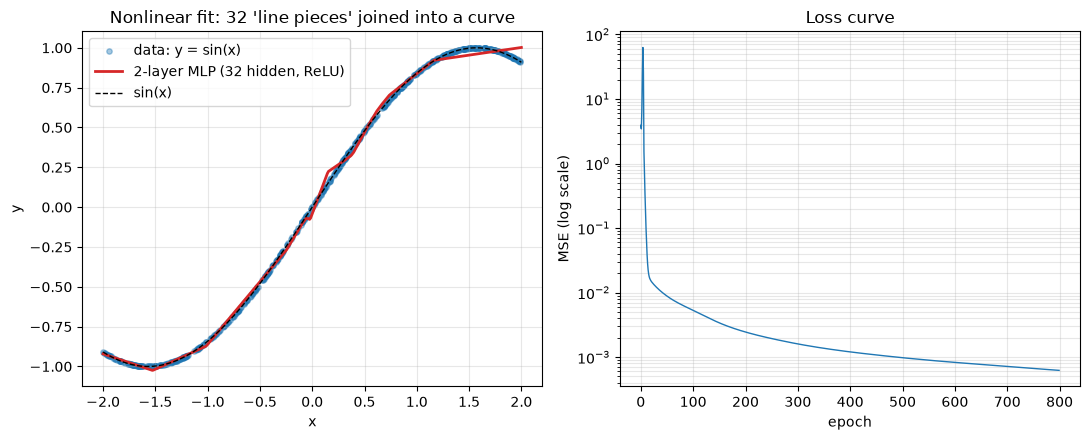

최종 MSE = 0.0006


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

xs = np.linspace(-2.0, 2.0, 400).reshape(-1, 1)
fit = (relu(xs @ W1 + b1) @ W2 + b2).ravel()

axes[0].scatter(x, y, s=15, alpha=0.4, c="tab:blue", label="data: y = sin(x)")
axes[0].plot(xs, fit, c="tab:red", lw=2, label="2-layer MLP (32 hidden, ReLU)")
axes[0].plot(xs, np.sin(xs), "k--", lw=1, label="sin(x)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Nonlinear fit: 32 'line pieces' joined into a curve")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(losses, lw=1)
axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("MSE (log scale)")
axes[1].set_title("Loss curve")
axes[1].grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()
print("최종 MSE =", round(losses[-1], 4))

## 5. PyTorch 세 줄 루프: y = 2x+1

본문의 코드 그대로 — `MLP(1, 16, 1)`, Adam lr=0.01, 200 에포크, 시드 0.
"손실이 5.5 → 0.003으로 줄고, 예측이 0.23 → 3.02로 수렴한다"는 흐름을 확인한다.


50 에포크 후 손실:    0.1688
100 에포크 후 손실:   0.0207
최종 손실:            0.0028
x=1일 때 예측:        3.016 (정답: 3.0)


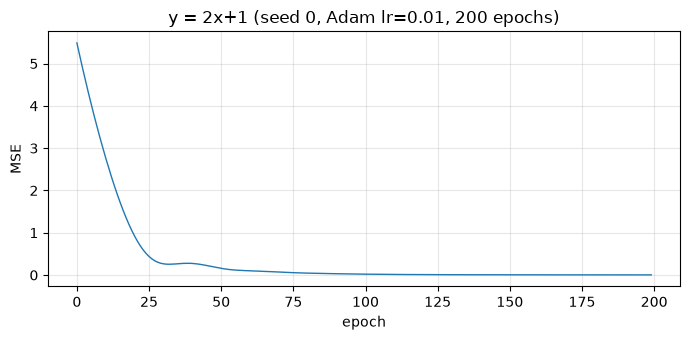

In [8]:
torch.manual_seed(0)
model = MLP(1, 16, 1)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

Xd = torch.rand(64, 1) * 4 - 2
yd = 2 * Xd + 1

losses = []
for epoch in range(200):
    loss = loss_fn(model(Xd), yd)
    optimizer.zero_grad()      # 1) 이전 에포크 그래디언트 초기화
    loss.backward()            # 2) 역전파 — .grad 필드에 채움
    optimizer.step()           # 3) theta <- theta - eta * grad
    losses.append(loss.item())

print("50 에포크 후 손실:   ", round(losses[49], 4))
print("100 에포크 후 손실:  ", round(losses[99], 4))
print("최종 손실:           ", round(losses[-1], 4))
with torch.no_grad():
    print("x=1일 때 예측:       ", round(model(torch.tensor([[1.0]])).item(), 3),
          "(정답: 3.0)")

plt.figure(figsize=(7, 3.5))
plt.plot(losses, lw=1)
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.title("y = 2x+1 (seed 0, Adam lr=0.01, 200 epochs)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. `zero_grad()`를 빼먹으면?

PyTorch의 `.backward()`는 그래디언트를 **초기화하지 않고 축적**한다.
`zero_grad()` 없이 `backward() → step()`만 반복하면, 에포크 2부터 "에포크 1 +
에포크 2 + …"의 그래디언트로 업데이트하게 되어 손실이 발산한다 —
본문 "자주 하는 실수 2"의 현상이다. 같은 시드로 실행하고 비교한다.


/tmp/ipykernel_402687/1768765273.py:32: UserWarning: Glyph 45572 (\N{HANGUL SYLLABLE NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_402687/1768765273.py:32: UserWarning: Glyph 46973 (\N{HANGUL SYLLABLE RAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_402687/1768765273.py:32: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_402687/1768765273.py:32: UserWarning: Glyph 54952 (\N{HANGUL SYLLABLE HYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_402687/1768765273.py:32: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_402687/1768765273.py:32: UserWarning: Glyph 44057 (\N{HANGUL SYLLABLE GAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_402687/1768765273.py:32: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
 

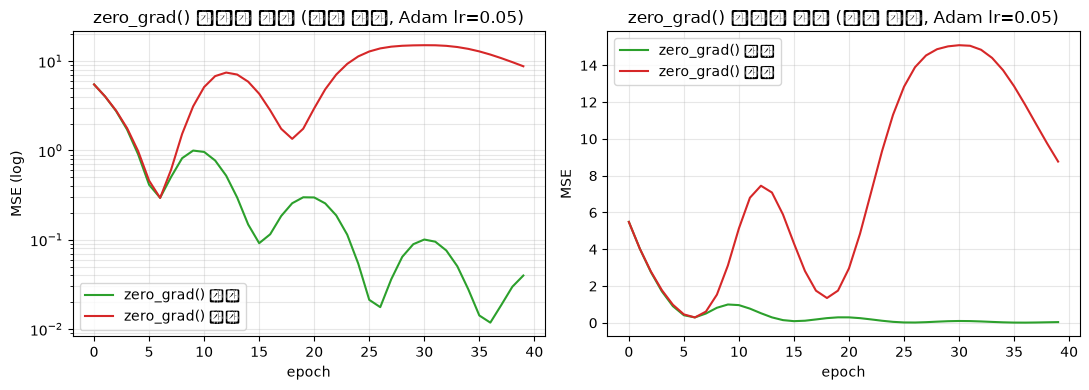

zero_grad() 있음:  최종 loss = 0.0398  (수렴)
zero_grad() 없음:  최종 loss = 8.77  (손실이 '갑자기 튀어' 발산)


In [9]:
def train(use_zero_grad, seed=0, epochs=40):
    torch.manual_seed(seed)
    m = MLP(1, 16, 1)
    opt = torch.optim.Adam(m.parameters(), lr=0.05)
    lf = nn.MSELoss()
    lns = []
    for e in range(epochs):
        loss = lf(m(Xd), yd)
        if use_zero_grad:
            opt.zero_grad()
        loss.backward()
        opt.step()
        lns.append(loss.item())
    return lns

with_g = train(use_zero_grad=True)
without_g = train(use_zero_grad=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, style in zip(axes, ["log", "linear"]):
    ax.plot(with_g, c="tab:green", lw=1.5, label="zero_grad() 있음")
    ax.plot(without_g, c="tab:red", lw=1.5, label="zero_grad() 없음")
    if style == "log":
        ax.set_yscale("log")
        ax.grid(alpha=0.3, which="both")
    else:
        ax.grid(alpha=0.3)
    ax.set_xlabel("epoch")
    ax.set_ylabel("MSE" + (" (log)" if style == "log" else ""))
    ax.set_title("zero_grad() 누락의 효과 (같은 시드, Adam lr=0.05)")
    ax.legend()
plt.tight_layout()
plt.show()

print(f"zero_grad() 있음:  최종 loss = {with_g[-1]:.4f}  (수렴)")
print(f"zero_grad() 없음:  최종 loss = {without_g[-1]:.2f}  (손실이 '갑자기 튀어' 발산)")

## 7. 이 뼈대가 강화학습에서 어디로 가는가

| 이 노트북에서 확인한 것 | 이번 학기에서 쓰이는 곳 |
|---|---|
| `zero_grad() → backward() → step()` 세 줄 | Ch.9 DQN, Ch.10~11 정책 신경망 — **하나도 변하지 않음** |
| 역전파 = "내려온 오차 × 활성 도함수 × 입력" | Ch.10 REINFORCE 정책 그래디언트 직접 유도 |
| 비선형 = 선형 조각들의 이어붙임 | 가치 함수 Q(s,a), 정책 π(a|s)를 근사하는 모든 네트워크 |
| 손실 정의가 바뀌면 문제도 바뀜 | 지도: (ŷ−y)² → DQN: 벨만 오차² → REINFORCE: −log π · G |

강화학습의 "새로움"은 학습 알고리즘이 아니라 **손실함수의 정의**에 있다 —
이 절에서 확인한 기계(세 줄)는 그대로다. 다음 절(1.3)에서 Gymnasium 환경을
세팅하고, 이 기계 위에 첫 번째 강화학습 문제를 올려놓는다.
